In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Excel file to inspect its structure
file_path = 'Desktop/Thesis_project/Thesis_Test_ML/Cell_3_Y7.XLSX'
data = pd.read_excel(file_path)

In [3]:
# Display the first few rows of the data for exploration
data.head()

,Material Description,Movement Type Text,Posting Date,Quantity,Amount in LC
0,Bottom Module,GI scrapping,2022-01-05,-1,-1003.8
1,Bottom Module,GI scrapping,2022-01-05,-2,-2007.6
2,Bottom Module,GI scrapping,2022-01-07,-1,-1003.8
3,Bottom Module,GI scrapping,2022-01-11,-1,-1003.8
4,Bottom Module,GI scrapping,2022-01-19,-1,-1003.8


In [4]:
# Data preprocessing
# Selecting features and target variable
columns_of_interest = [
    'Posting Date', 'Movement Type Text', 'Material Description','Quantity', 'Amount in LC'
]
data_subset = data[columns_of_interest].dropna()



In [5]:
# Encode categorical features (Material, Movement Type)
data_subset['Material Description'] = data_subset['Material Description'].astype('category').cat.codes
data_subset['Posting Date'] = data_subset['Posting Date'].astype('category').cat.codes

In [6]:
# Split data into features (X) and target (y)
X = data_subset[['Quantity', 'Posting Date', 'Material Description']]
y = data_subset['Amount in LC']



In [7]:
# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Train a Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [9]:
# Predict on test data
y_pred = model.predict(X_test)

In [10]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [11]:
mae, r2 #Mean Absolute Error (MAE): Close to zero, suggesting very small prediction errors.
        #R² Score: Zero, implying that the model isn't explaining variance in the target.

(197.7111326973559, 0.7734253642222607)

In [12]:
# Inspecting the distribution of the target variable (Amount in LC)
y.describe(), y.value_counts()

(count      375.000000
 mean     -1423.663707
 std       1444.529212
 min     -18068.660000
 25%      -1503.430000
 50%      -1122.160000
 75%      -1003.800000
 max       -952.250000
 Name: Amount in LC, dtype: float64,
 Amount in LC
 -1003.80     137
 -1644.29      44
 -1503.43      23
 -1245.25      17
 -2007.60      13
             ... 
 -14052.76      1
 -1331.90       1
 -1003.71       1
 -1331.95       1
 -3006.86       1
 Name: count, Length: 77, dtype: int64)

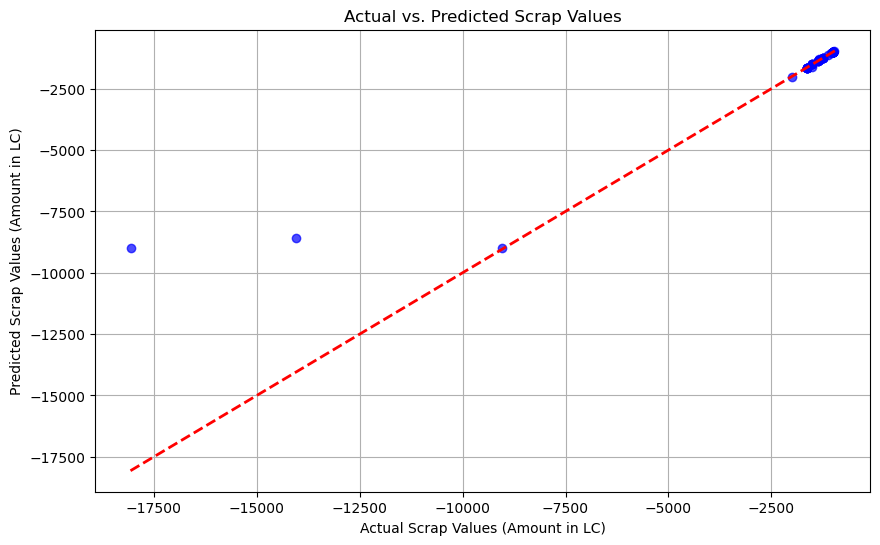

In [13]:
# Plotting Actual vs. Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)  # Ideal fit line
plt.xlabel("Actual Scrap Values (Amount in LC)")
plt.ylabel("Predicted Scrap Values (Amount in LC)")
plt.title("Actual vs. Predicted Scrap Values")
plt.grid(True)
plt.show()